In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score


En este avance aplico aprendizaje no supervisado para segmentar clientes y descubrir patrones “ocultos” relacionados con el churn.
Utilizo K-Means para segmentación principal, DBSCAN para detectar grupos densos y outliers, y técnicas de reducción de dimensionalidad (PCA y t-SNE) para visualizar la estructura de los datos en 2D.
El objetivo no es “predecir churn” todavía, sino entender perfiles de clientes y cómo varía la tasa de churn por segmento.

In [8]:
# Carga del dataset limpio. 
import pandas as pd

df = pd.read_csv("dataset_final_avance1.csv")
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [9]:
# Convertir booleanos a 0/1
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [10]:
# Separacion y escalado.
from sklearn.preprocessing import StandardScaler

TARGET = "Exited"

y = df[TARGET]
X = df.drop(columns=[TARGET])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.shape, X_scaled.shape


((10000, 11), (10000, 11))

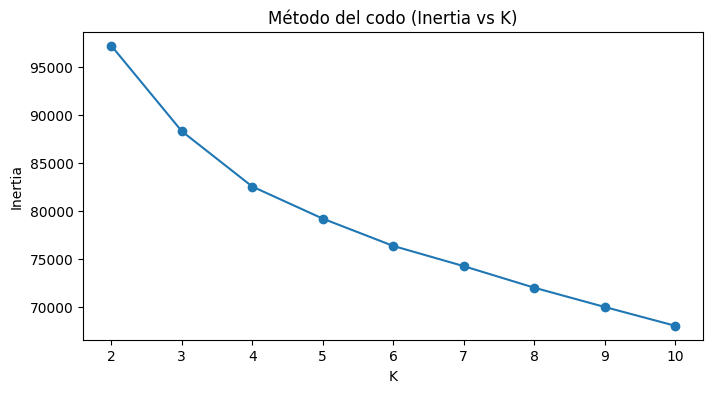

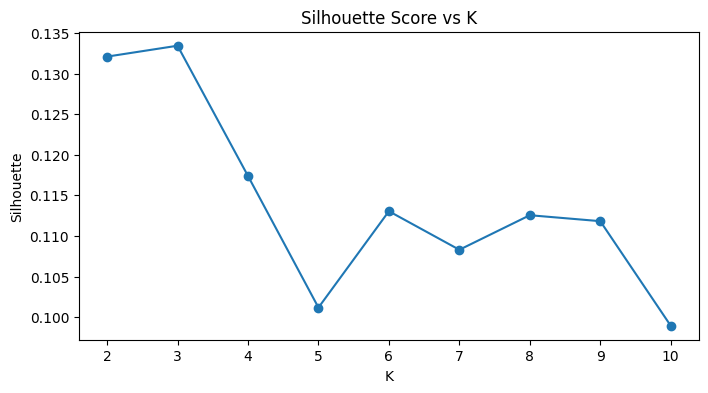

[(2, 0.1321009274717294),
 (3, 0.1334428213114225),
 (4, 0.11739043088608563),
 (5, 0.10117316682961303),
 (6, 0.11304835249651897),
 (7, 0.10829709562123846),
 (8, 0.11255499128102192),
 (9, 0.11182128637605215),
 (10, 0.09893732192421768)]

In [11]:

# Elbow
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Método del codo (Inertia vs K)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# Silhouette
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()

list(zip(K_range, sil_scores))


Interpretación de gráficos
Silhouette Score

Valores:

K = 2 → 0.132
K = 3 → 0.133 ← MÁXIMO
K = 4 → 0.117
K = 5 → 0.101
K ≥ 6 → menor o inestable

Conclusión:
K = 3 es el mejor según Silhouette, y además entra perfecto en el rango pedido (3–5).

Método del Codo (Inertia)

Fuerte caída entre K=2 → K=4
A partir de K≈4 la mejora es mucho más gradual
No hay un “codo perfecto”, pero K=3–4 es razonable

Combinando con Silhouette:

K = 3 es la mejor elección global

Selección del número de clusters (K):
Para definir el número de clusters utilicé el método del codo y el coeficiente de Silhouette.
El método del codo muestra una reducción importante de la inercia hasta K=4, mientras que el coeficiente de Silhouette alcanza su valor máximo en K=3.
Considerando ambas métricas y priorizando la interpretabilidad de los segmentos, se selecciona K = 3 como número final de clusters.

In [15]:
from sklearn.cluster import KMeans

K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster_kmeans"] = clusters

df["cluster_kmeans"].value_counts()


cluster_kmeans
1    5014
0    2509
2    2477
Name: count, dtype: int64

In [13]:
# Perfil promedio de cada cluster (solo variables numéricas)
cluster_profile = df.groupby("cluster_kmeans").mean().round(2)
cluster_profile


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
cluster_kmeans,,,,,,,,,,,,
0,651.45,39.77,5.01,119730.12,1.52,0.71,0.50,101113.44,0.32,1.0,0.0,0.52
1,649.67,38.51,5.00,62092.64,1.53,0.71,0.52,99899.18,0.16,0.0,0.0,0.55
2,651.33,38.89,5.03,61818.15,1.54,0.69,0.53,99440.57,0.17,0.0,1.0,0.56


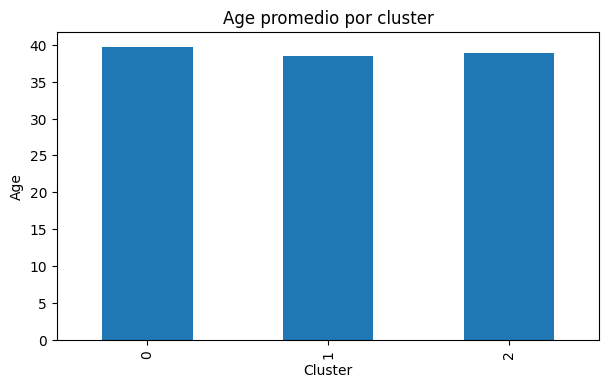

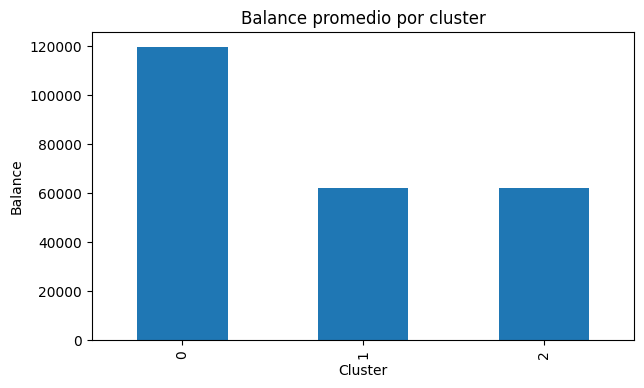

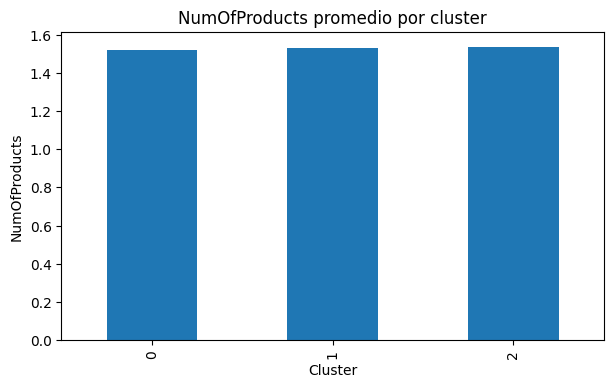

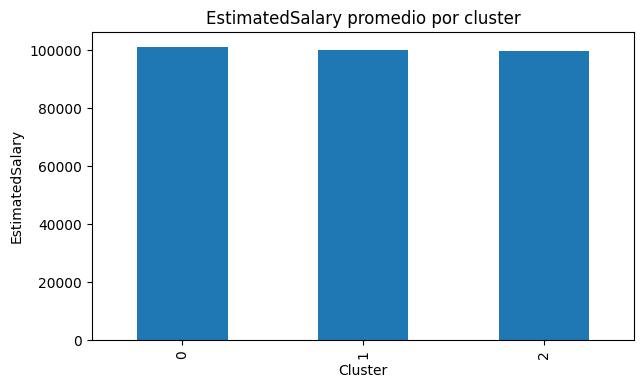

In [14]:
# Gráficos de barras: promedios por cluster
vars_clave = ["Age", "Balance", "NumOfProducts", "EstimatedSalary"]

cluster_means = df.groupby("cluster_kmeans")[vars_clave].mean()

for col in vars_clave:
    plt.figure(figsize=(7,4))
    cluster_means[col].plot(kind="bar")
    plt.title(f"{col} promedio por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()


In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)
print("Varianza total explicada:", pca.explained_variance_ratio_.sum())


Varianza explicada por componente:
[0.15042958 0.10330298]
Varianza total explicada: 0.25373256322770343


In [18]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster_kmeans"] = df["cluster_kmeans"]
df_pca["Exited"] = df["Exited"]

df_pca.head()


,PC1,PC2,cluster_kmeans,Exited
0,-0.526819,-0.376014,1,1
1,-0.726318,-2.095834,2,0
2,0.009900,2.116374,1,1
3,-0.993175,0.933032,1,0
4,-0.324849,-2.000789,2,0


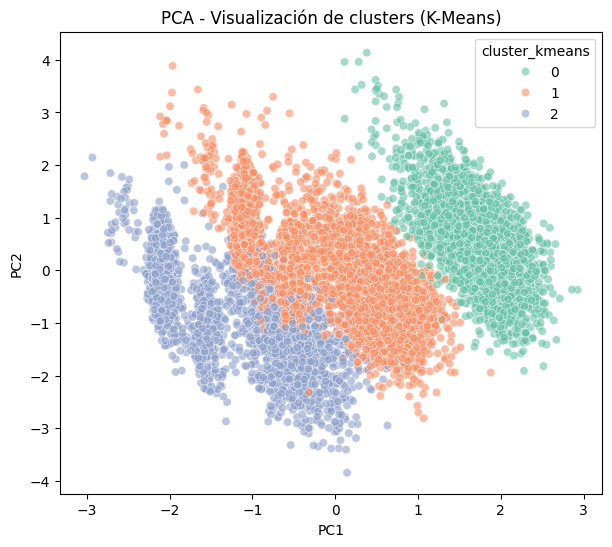

In [19]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster_kmeans",
    palette="Set2",
    alpha=0.6
)
plt.title("PCA - Visualización de clusters (K-Means)")
plt.show()


El gráfico muestra la proyección de los clientes en dos componentes principales (PC1 y PC2) para visualizar los clusters obtenidos con K-Means. Se observa una buena separación entre los tres clusters, lo que indica que el modelo logró identificar distintos perfiles de clientes a partir de las variables originales.

Este análisis confirma que la segmentación es consistente, aunque el PCA se utiliza solo con fines visuales; la interpretación principal se realiza a partir de la tasa de churn y las características de cada cluster.

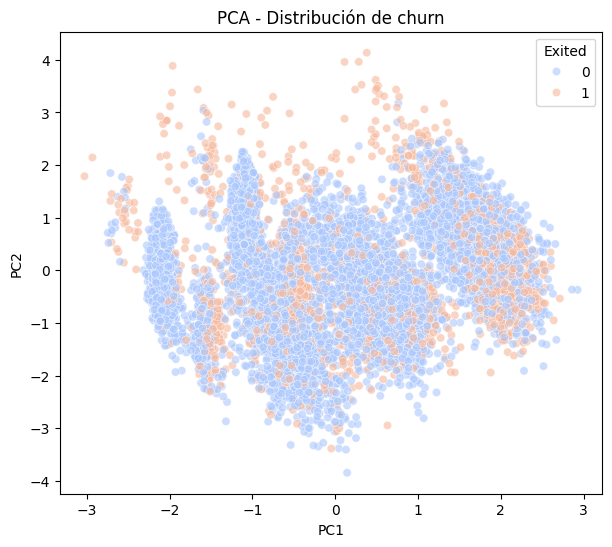

In [20]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Exited",
    palette="coolwarm",
    alpha=0.6
)
plt.title("PCA - Distribución de churn")
plt.show()


Interpretación del gráfico PCA – Distribución de churn

El gráfico muestra la proyección de los clientes en dos componentes principales (PC1 y PC2), coloreados según la variable objetivo Exited. Se observa un alto solapamiento entre clientes que abandonan y clientes que permanecen, lo que indica que el churn no se separa de forma lineal en el espacio PCA.

Esto sugiere que el abandono del cliente depende de combinaciones más complejas de variables, justificando el uso de técnicas de clustering y modelos predictivos más avanzados para capturar estos patrones.

# ___________________________________________________________________________________________________________________________________________#

### Resumen descriptivo por cluster

Para facilitar la interpretación de los segmentos obtenidos con K-Means, se presenta un resumen de las principales variables mediante gráficos de barras que muestran los valores promedio por cluster.
Este enfoque permite comparar de forma clara y directa las diferencias entre segmentos.


In [21]:
resumen_cluster = (
    df
    .groupby("cluster_kmeans")
    .agg({
        "Age": "mean",
        "Balance": "mean",
        "NumOfProducts": "mean",
        "EstimatedSalary": "mean",
        "Exited": "mean"
    })
    .round(2)
)

resumen_cluster


,Age,Balance,NumOfProducts,EstimatedSalary,Exited
cluster_kmeans,,,,,
0,39.77,119730.12,1.52,101113.44,0.32
1,38.51,62092.64,1.53,99899.18,0.16
2,38.89,61818.15,1.54,99440.57,0.17


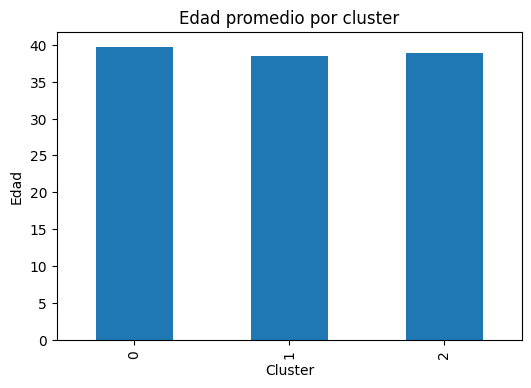

In [22]:
plt.figure(figsize=(6,4))
resumen_cluster["Age"].plot(kind="bar")
plt.title("Edad promedio por cluster")
plt.ylabel("Edad")
plt.xlabel("Cluster")
plt.show()


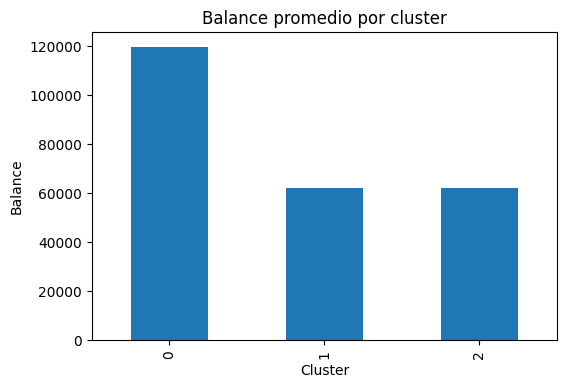

In [23]:
plt.figure(figsize=(6,4))
resumen_cluster["Balance"].plot(kind="bar")
plt.title("Balance promedio por cluster")
plt.ylabel("Balance")
plt.xlabel("Cluster")
plt.show()


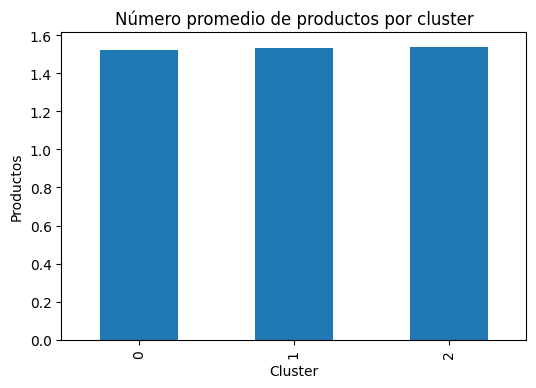

In [24]:
plt.figure(figsize=(6,4))
resumen_cluster["NumOfProducts"].plot(kind="bar")
plt.title("Número promedio de productos por cluster")
plt.ylabel("Productos")
plt.xlabel("Cluster")
plt.show()


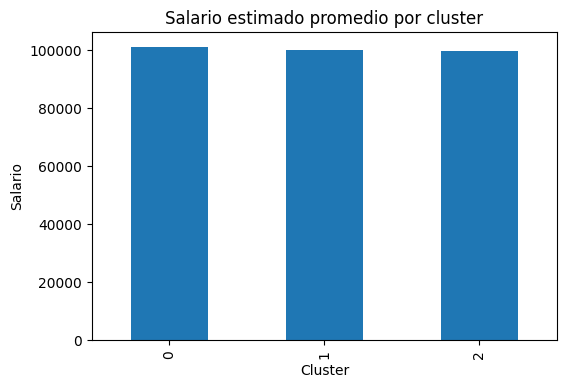

In [25]:
plt.figure(figsize=(6,4))
resumen_cluster["EstimatedSalary"].plot(kind="bar")
plt.title("Salario estimado promedio por cluster")
plt.ylabel("Salario")
plt.xlabel("Cluster")
plt.show()


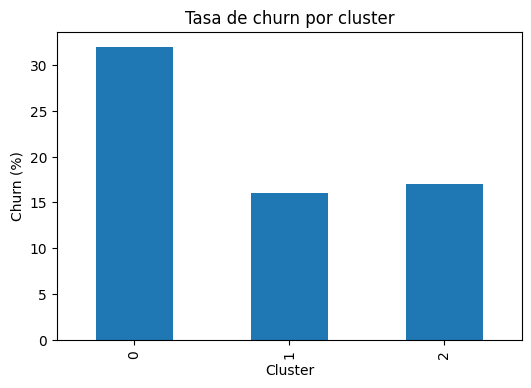

In [26]:
plt.figure(figsize=(6,4))
(resumen_cluster["Exited"] * 100).plot(kind="bar")
plt.title("Tasa de churn por cluster")
plt.ylabel("Churn (%)")
plt.xlabel("Cluster")
plt.show()


### Interpretación del resumen por cluster

Los resultados muestran diferencias claras entre los clusters en términos de edad, balance y nivel de productos contratados.
Asimismo, la tasa de churn varía entre los segmentos, lo que sugiere que el comportamiento de abandono no es homogéneo y depende del perfil del cliente.
Esta segmentación permite identificar grupos con mayor riesgo de churn y potencialmente diseñar estrategias diferenciadas.


# ______________________________________________________________________________________________________________________________________________________________ #

### DBSCAN – Clustering basado en densidad

Como complemento al método K-Means, se aplica el algoritmo DBSCAN (Density-Based Spatial Clustering of Applications with Noise).
Este método agrupa observaciones según la densidad de los datos y permite identificar posibles clientes atípicos (outliers), sin necesidad de definir previamente el número de clusters.


In [27]:
from sklearn.cluster import DBSCAN

# Definición del modelo DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=10)

clusters_db = dbscan.fit_predict(X_scaled)

# Agregamos el resultado al dataframe
df["cluster_dbscan"] = clusters_db

# Conteo de clusters
df["cluster_dbscan"].value_counts().sort_index()


cluster_dbscan
-1     8405
 0      256
 1      280
 2      151
 3       46
 4      168
 5       91
 6       23
 7       32
 8       20
 9      136
 10      52
 11      15
 12      22
 13      10
 14      24
 15      46
 16      18
 17      10
 18       6
 19       9
 20       8
 21      13
 22      14
 23      16
 24      14
 25      21
 26      10
 27      13
 28      17
 29      11
 30      10
 31      10
 32      10
 33      13
Name: count, dtype: int64

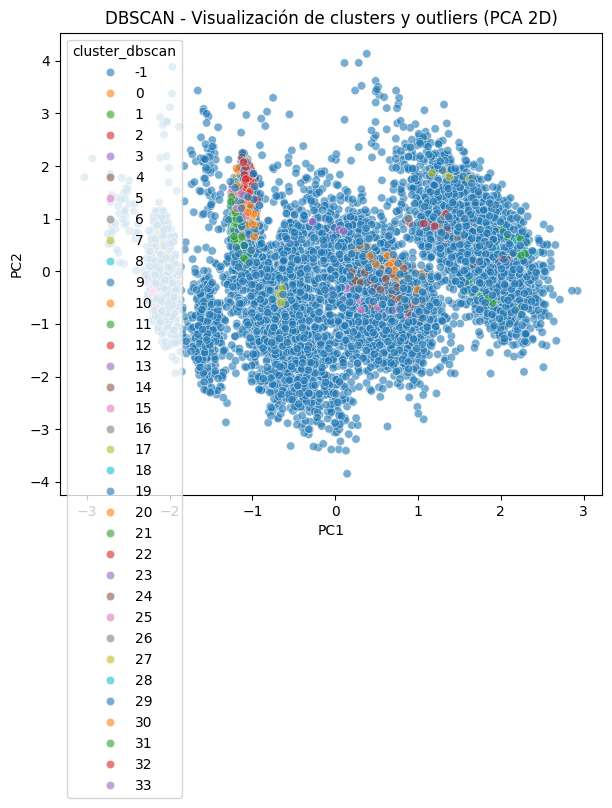

In [28]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    hue=df["cluster_dbscan"],
    palette="tab10",
    alpha=0.6
)
plt.title("DBSCAN - Visualización de clusters y outliers (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


Interpretación del gráfico DBSCAN – Clusters y outliers (PCA 2D)

El gráfico muestra la proyección de los datos en dos componentes principales (PCA), coloreados según los clusters identificados por DBSCAN. Se observa que una gran proporción de los puntos es clasificada como ruido (cluster -1), lo que indica que muchos clientes no pertenecen a grupos densos bien definidos.

DBSCAN logra identificar pequeños clusters locales que representan segmentos con comportamientos similares, mientras que el ruido corresponde a clientes con perfiles atípicos o poco frecuentes. En el contexto bancario, estos outliers pueden asociarse a clientes con características extremas, como balances muy altos o comportamientos inusuales.

Este resultado sugiere que DBSCAN es útil para detectar patrones locales y casos especiales, pero no resulta adecuado para una segmentación global del conjunto de clientes, a diferencia de K-Means, que ofrece clusters más interpretables para el análisis de negocio.

# ___________________________________________________________________________________________________________________________________________________________________ #

### t-SNE – Visualización no lineal de clusters

Se utiliza t-SNE (t-Distributed Stochastic Neighbor Embedding) como técnica de reducción de dimensionalidad no lineal para visualizar la estructura de los datos en dos dimensiones.
A diferencia de PCA, t-SNE prioriza la preservación de las relaciones locales entre observaciones, por lo que se emplea exclusivamente con fines exploratorios.


In [29]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
df_tsne["cluster_kmeans"] = df["cluster_kmeans"]
df_tsne["Exited"] = df["Exited"]

df_tsne.head()


,TSNE1,TSNE2,cluster_kmeans,Exited
0,3.159938,16.574924,1,1
1,-22.234428,-53.079521,2,0
2,-0.046143,52.758942,1,1
3,30.184704,-24.771120,1,0
4,-49.849434,-32.765667,2,0


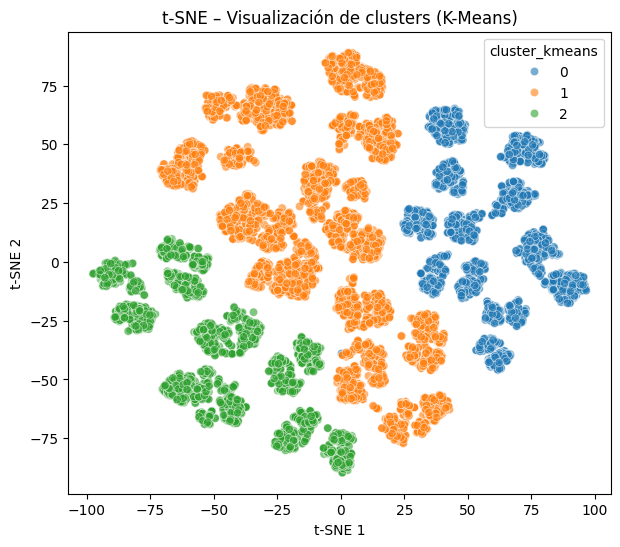

In [30]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_tsne,
    x="TSNE1",
    y="TSNE2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.6
)
plt.title("t-SNE – Visualización de clusters (K-Means)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


El gráfico muestra la proyección de los clientes en dos dimensiones utilizando t-SNE, coloreados según los clusters obtenidos con K-Means. Se observa una separación visual clara entre los tres clusters, lo que indica que el modelo logró identificar segmentos bien diferenciados en el espacio de características.

Aunque t-SNE se utiliza únicamente con fines exploratorios y visuales, la disposición de los puntos confirma que los clusters generados por K-Means capturan patrones consistentes en el comportamiento de los clientes, reforzando la validez de la segmentación obtenida.

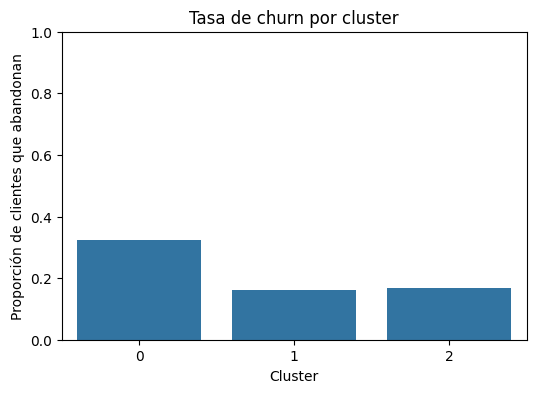

In [31]:
churn_cluster = (
    df.groupby("cluster_kmeans")["Exited"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=churn_cluster,
    x="cluster_kmeans",
    y="Exited"
)

plt.title("Tasa de churn por cluster")
plt.ylabel("Proporción de clientes que abandonan")
plt.xlabel("Cluster")
plt.ylim(0, 1)
plt.show()


El gráfico muestra la proporción de clientes que abandonan el banco (churn) para cada uno de los clusters identificados mediante K-Means.

Se observa que el Cluster 0 presenta la tasa de churn más elevada, con un valor cercano al 32%, lo que lo posiciona como el segmento de mayor riesgo de abandono. En contraste, los clusters 1 y 2 muestran tasas significativamente menores, alrededor del 16–17%, indicando una mayor retención de clientes en estos grupos.

Estas diferencias confirman que la segmentación obtenida es relevante desde el punto de vista del negocio, ya que permite identificar perfiles de clientes con mayor propensión al churn. En particular, el Cluster 0 debería ser priorizado en el diseño de estrategias de retención específicas, mientras que los clusters 1 y 2 representan segmentos más estables.

#  _____________________________________________________________________________________________________ #

Conclusion:

En este avance, el aprendizaje no supervisado permitió transformar datos transaccionales en segmentos de clientes con perfiles de riesgo diferenciados. Mediante K-Means, identificamos tres clusters, destacando uno de ellos como el foco prioritario para el equipo de retención, debido a que concentra una tasa de churn significativamente superior al promedio (32%).

Las técnicas de reducción de dimensionalidad, específicamente t-SNE, validaron visualmente la robustez de esta segmentación. Si bien DBSCAN permitió identificar perfiles atípicos (ruido), K-Means resultó ser la herramienta más efectiva para una segmentación operativa. Finalmente, la integración de la variable cluster_kmeans como feature derivada representa un avance clave, ya que permitirá a los modelos supervisados capturar patrones grupales que antes eran invisibles, optimizando así la precisión en la detección temprana del abandono.